# Ejercicio de programación Regresión Polinomial

In [23]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot

In [24]:
#from google.colab import drive
#drive.mount('/content/drive')

In [25]:
# Cargar datos - SkillCraft1_Dataset
data = pd.read_csv('SkillCraft1_Dataset.csv')

# Limpiar datos: remover filas con valores faltantes ('?')
data_clean = data[(data['Age'] != '?') & (data['LeagueIndex'] != '?')].copy()

# Usar Age como variable independiente (X) y LeagueIndex como dependiente (y)
X = data_clean[['Age']].copy()
y = data_clean['LeagueIndex'].values
m = y.size
print(f'Dataset limpio: {len(data_clean)} registros')
print(f'Primeros 5 datos:')
print(X.head())

Dataset limpio: 3340 registros
Primeros 5 datos:
  Age
0  27
1  23
2  30
3  19
4  32


In [26]:
# Importamos la clase de Regresión Lineal de scikit-learn
from sklearn.linear_model import LinearRegression

# para generar características polinómicas
from sklearn.preprocessing import PolynomialFeatures

pf = PolynomialFeatures(degree = 2)    # usaremos polinomios de grado 2
print(f'X shape antes: {X.shape}')
X_poly = pf.fit_transform(X.values.reshape(-1,1))  # transformamos la entrada en polinómica
print(f'X shape después (grado 2): {X_poly.shape}')
regresion_lineal = LinearRegression() # creamos una instancia de LinearRegression

# instruimos a la regresión lineal que aprenda de los datos (ahora polinómicos) (X,y)
regresion_lineal.fit(X_poly, y)

# vemos los parámetros que ha estimado la regresión lineal
print('Coeficientes (theta) = ' + str(regresion_lineal.coef_))
print('Término independiente (b) = ' + str(regresion_lineal.intercept_))

# Guardamos X_poly para usarlo en predicciones
X = X_poly

X shape antes: (3340, 1)
X shape después (grado 2): (3340, 3)
Coeficientes (theta) = [ 0.          0.25785587 -0.00627033]
Término independiente (b) = 1.5886057261982813


In [27]:
from sklearn.metrics import mean_squared_error # importamos el cálculo del error cuadrático medio (MSE)
# Predecimos los valores y para los datos usados en el entrenamiento
prediccion_entrenamiento = regresion_lineal.predict(X)
# Calculamos el Error Cuadrático Medio (MSE = Mean Squared Error)
mse = mean_squared_error(y_true = y, y_pred = prediccion_entrenamiento)
# La raíz cuadrada del MSE es el RMSE
rmse = np.sqrt(mse)
print('Error Cuadrático Medio (MSE) = ' + str(mse))
print('Raíz del Error Cuadrático Medio (RMSE) = ' + str(rmse))
# calculamos el coeficiente de determinación R2
r2 = regresion_lineal.score(X, y)
print('Coeficiente de Determinación R2 = ' + str(r2))

Error Cuadrático Medio (MSE) = 2.0286193589765658
Raíz del Error Cuadrático Medio (RMSE) = 1.424296092452888
Coeficiente de Determinación R2 = 0.03204365162249212


In [28]:
def plotData(x, y):
    #Grafica los puntos x e y en una figura nueva.

    fig = pyplot.figure()  # abre una nueva figura

    pyplot.plot(x, y, 'ro', ms=10, mec='k')
    pyplot.xlabel('Age (Edad)')
    pyplot.ylabel('LeagueIndex (Liga/Habilidad)')
    pyplot.grid(True)

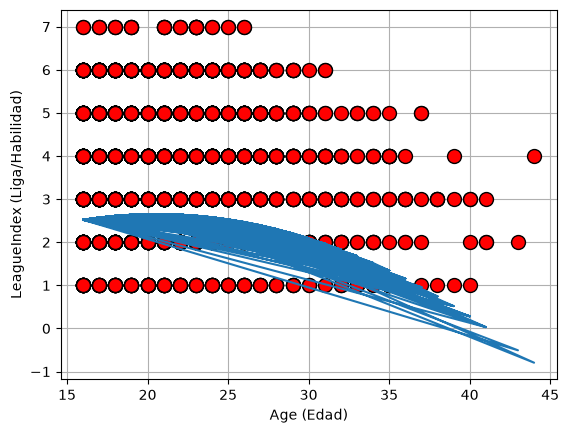

In [29]:
plotData(X[:,1], y)
pyplot.plot(X[:, 1], np.dot(X, regresion_lineal.coef_), '-')

In [30]:
# Predicción para edad 25
X_test = np.array([25])
pf_pred = PolynomialFeatures(degree = 2)    # mismo grado que el modelo
X_test_poly = pf_pred.fit_transform(X_test.reshape(-1,1))
prediccion_test = regresion_lineal.predict(X_test_poly)
print(f'Predicción de Liga para edad 25: {prediccion_test[0]:.2f}')
print('(Escala: 1=Bronze, 2=Silver, 3=Gold, 4=Platinum, 5=Diamond, 6=Master, 7=GrandMaster)')

Predicción de Liga para edad 25: 4.12
(Escala: 1=Bronze, 2=Silver, 3=Gold, 4=Platinum, 5=Diamond, 6=Master, 7=GrandMaster)
